<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab_project/blob/main/NIFTY_Price_Prediction_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIFTY Price Prediction and Market Direction Classification
## Using Machine Learning — Regression & Classification

---

**Objective:**  
This project aims to:
1. **Predict the next day's closing price** of NIFTY 50 (Regression)
2. **Predict market direction** — whether the market will go UP or DOWN next day (Classification)

**Dataset:** Historical NIFTY 50 CSV with columns: Date, Open, High, Low, Close, Volume

**Models Used:**
- Regression: Linear Regression, Decision Tree, Random Forest, XGBoost, SVR
- Classification: Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM

**Key Evaluation Metrics:**
- Regression: MAE, RMSE, R²
- Classification: Accuracy, Precision, Recall, F1, ROC-AUC

---

## 📦 Install & Import Libraries

In [65]:
# Install required packages (run once in Colab)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    ConfusionMatrixDisplay, classification_report
)

# XGBoost
from xgboost import XGBRegressor, XGBClassifier

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
# SECTION 1: Data Understanding
---
We begin by loading the dataset and thoroughly understanding its structure, types, and quality.

In [66]:
# ─── LOAD DATASET ───────────────────────────────────────────────────────────
# Upload your CSV in Colab using: from google.colab import files; files.upload()
# Then update the filename below.

df = pd.read_csv('/data 3.csv')   # <-- Replace with your filename

# Parse Date column
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 6315 rows × 5 columns


In [67]:
# ─── FIRST LOOK ──────────────────────────────────────────────────────────────
print('=== First 5 rows ===')
display(df.head())

print('\n=== Last 5 rows ===')
display(df.tail())

=== First 5 rows ===


,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3



=== Last 5 rows ===


,Date,Open,High,Low,Close
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15
6314,2025-05-26,24919.35,25079.20,24900.50,25001.15


In [68]:
# ─── COLUMN INFO ─────────────────────────────────────────────────────────────
print('=== Data Types & Non-Null Counts ===')
print(df.info())

print('\n=== Column Names ===')
print(df.columns.tolist())

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6315 non-null   datetime64[ns]
 1   Open    6315 non-null   float64       
 2   High    6315 non-null   float64       
 3   Low     6315 non-null   float64       
 4   Close   6315 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 246.8 KB
None

=== Column Names ===
['Date', 'Open', 'High', 'Low', 'Close']


In [69]:
# ─── MISSING VALUES ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
display(missing_df)

if missing.sum() == 0:
    print('\n✅ No missing values found.')
else:
    print(f'\n⚠️ Total missing values: {missing.sum()}')

=== Missing Values ===


,Missing Count,Missing %
Date,0,0.0
Open,0,0.0
High,0,0.0
Low,0,0.0
Close,0,0.0



✅ No missing values found.


In [70]:
# ─── SUMMARY STATISTICS ───────────────────────────────────────────────────────
print('=== Summary Statistics ===')
display(df.describe().T.round(2))

print(f'\nDate range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total trading days: {len(df)}')

=== Summary Statistics ===


,count,mean,min,25%,50%,75%,max,std
Date,6315,2012-08-30 17:56:31.353919232,2000-01-03 00:00:00,2006-04-19 12:00:00,2012-08-22 00:00:00,2019-01-09 12:00:00,2025-05-26 00:00:00,NaN
Open,6315.0,7813.645732,853.0,2851.375,5803.05,10786.175,26248.25,6248.404053
High,6315.0,7858.810665,877.0,2884.1,5857.35,10830.625,26277.35,6270.43442
Low,6315.0,7758.153325,849.95,2812.65,5749.5,10727.775,26151.4,6216.988574
Close,6315.0,7809.684806,854.2,2850.6,5796.9,10781.725,26216.05,6244.654057



Date range: 2000-01-03 → 2025-05-26
Total trading days: 6315


**Observations from Section 1:**
- The dataset spans several years of daily NIFTY 50 trading data.
- Columns include OHLCV (Open, High, Low, Close, Volume) — standard financial time series format.
- We check for missing values before any processing.
- The Close column will be our primary prediction target.

---
# SECTION 2: Exploratory Data Analysis (EDA)
---
We visualize the data to understand trends, volatility, volume patterns, and distributions.

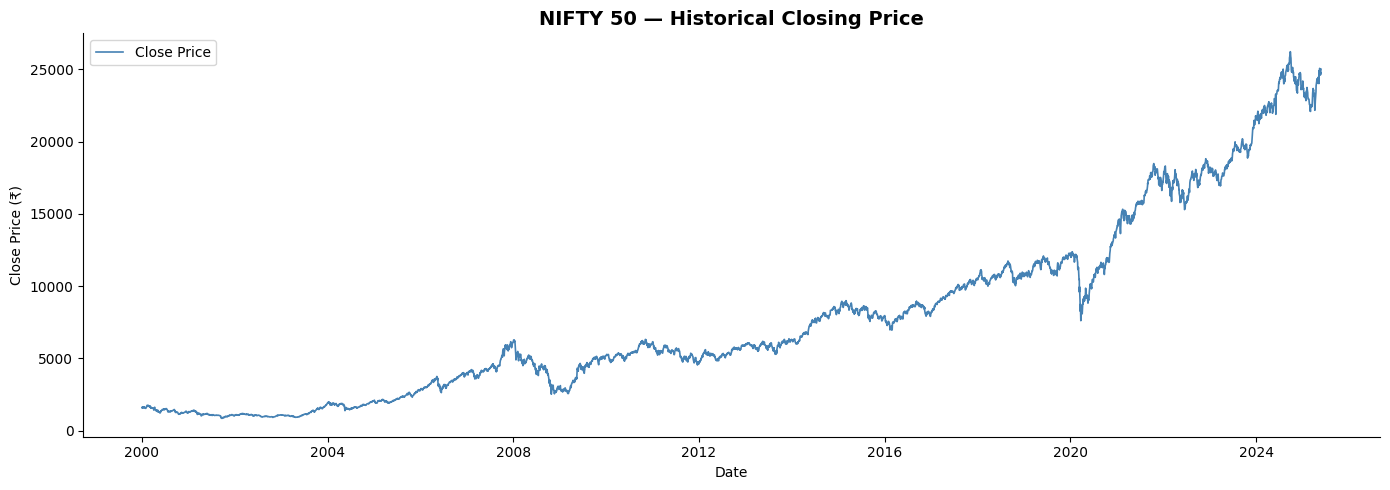

The chart shows the long-term upward trend of NIFTY 50 with periodic corrections.


In [71]:
# ─── 2.1 CLOSING PRICE TREND ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
ax.set_title('NIFTY 50 — Historical Closing Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (₹)')
ax.legend()
plt.tight_layout()
plt.show()
print('The chart shows the long-term upward trend of NIFTY 50 with periodic corrections.')

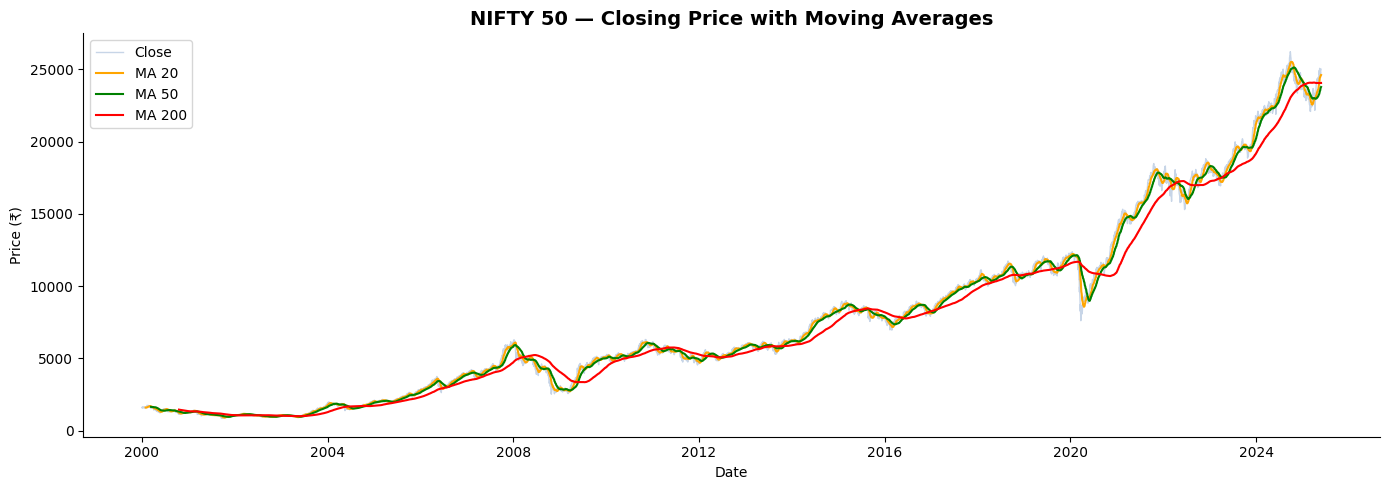

Moving averages smooth out noise and reveal the overall trend direction.
When short-term MA crosses above long-term MA → bullish signal (Golden Cross).


In [72]:
# ─── 2.2 MOVING AVERAGES OVERLAY ──────────────────────────────────────────────
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Close'],  color='lightsteelblue', linewidth=1,   label='Close',  alpha=0.7)
ax.plot(df['Date'], df['MA_20'],  color='orange',         linewidth=1.5,  label='MA 20')
ax.plot(df['Date'], df['MA_50'],  color='green',          linewidth=1.5,  label='MA 50')
ax.plot(df['Date'], df['MA_200'], color='red',            linewidth=1.5,  label='MA 200')
ax.set_title('NIFTY 50 — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (₹)')
ax.legend()
plt.tight_layout()
plt.show()

print('Moving averages smooth out noise and reveal the overall trend direction.')
print('When short-term MA crosses above long-term MA → bullish signal (Golden Cross).')

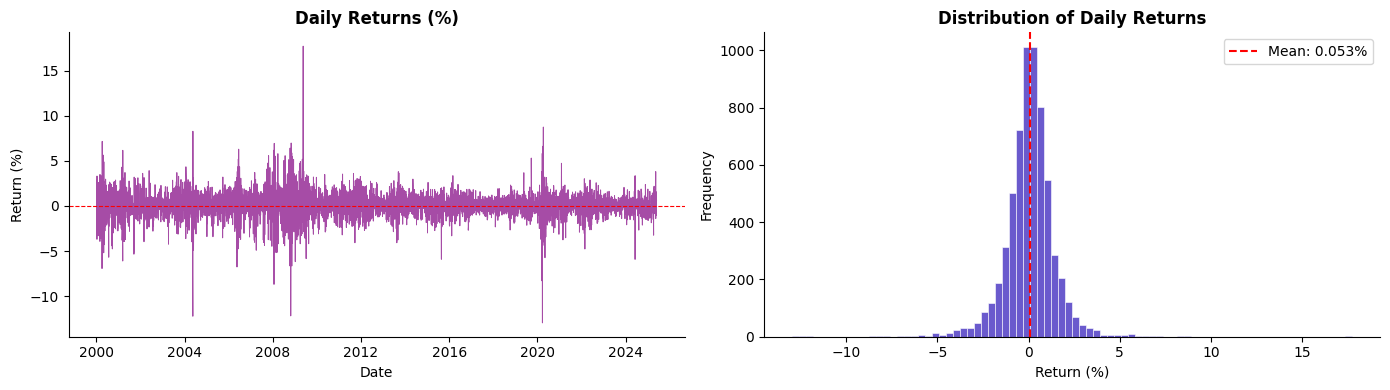

Mean daily return : 0.0531%
Std daily return  : 1.3766%
Skewness          : -0.2240
Kurtosis          : 11.2482

Note: Fat tails and slight negative skewness are typical of equity returns.


In [73]:
# ─── 2.3 DAILY RETURNS ────────────────────────────────────────────────────────
df['Daily_Return'] = df['Close'].pct_change() * 100  # in %

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['Date'], df['Daily_Return'], color='purple', linewidth=0.7, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Daily Returns (%)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return (%)')

axes[1].hist(df['Daily_Return'].dropna(), bins=80, color='slateblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.3f}%')
axes[1].set_title('Distribution of Daily Returns', fontweight='bold')
axes[1].set_xlabel('Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean daily return : {df["Daily_Return"].mean():.4f}%')
print(f'Std daily return  : {df["Daily_Return"].std():.4f}%')
print(f'Skewness          : {df["Daily_Return"].skew():.4f}')
print(f'Kurtosis          : {df["Daily_Return"].kurtosis():.4f}')
print('\nNote: Fat tails and slight negative skewness are typical of equity returns.')

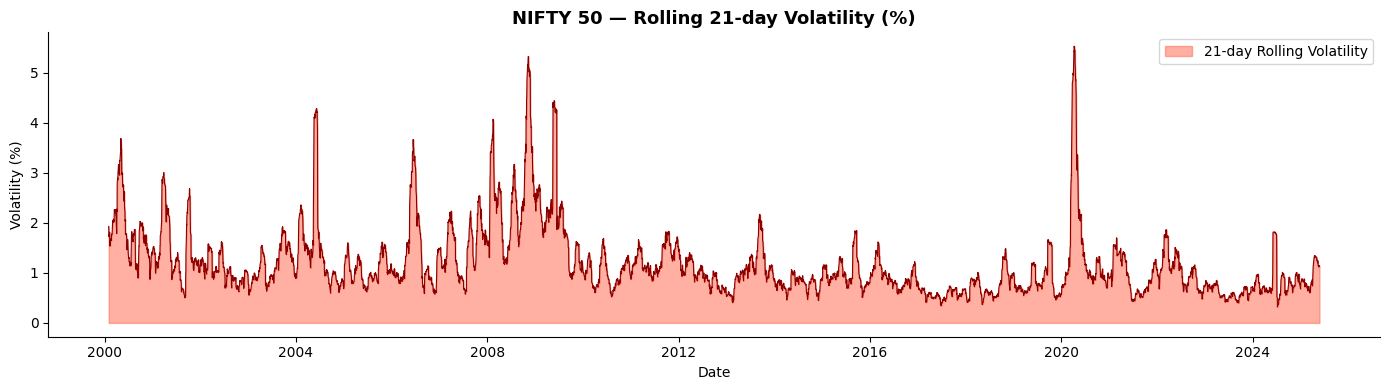

Volatility spikes indicate market stress periods (e.g., COVID crash in 2020).


In [74]:
# ─── 2.4 VOLATILITY (ROLLING STD) ────────────────────────────────────────────
df['Volatility_21'] = df['Daily_Return'].rolling(21).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df['Date'], df['Volatility_21'], color='tomato', alpha=0.5, label='21-day Rolling Volatility')
ax.plot(df['Date'], df['Volatility_21'], color='darkred', linewidth=0.8)
ax.set_title('NIFTY 50 — Rolling 21-day Volatility (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

print('Volatility spikes indicate market stress periods (e.g., COVID crash in 2020).')

Columns found: ['Date', 'Open', 'High', 'Low', 'Close', 'MA_20', 'MA_50', 'MA_200', 'Daily_Return', 'Volatility_21']
Columns after rename: ['Date', 'Open', 'High', 'Low', 'Close', 'MA_20', 'MA_50', 'MA_200', 'Daily_Return', 'Volatility_21']
✅ Fixed. Columns now: ['Date', 'Open', 'High', 'Low', 'Close', 'MA_20', 'MA_50', 'MA_200', 'Daily_Return', 'Volatility_21', 'Volume']
✅ Feature list updated. Using 34 features (Volume features removed).


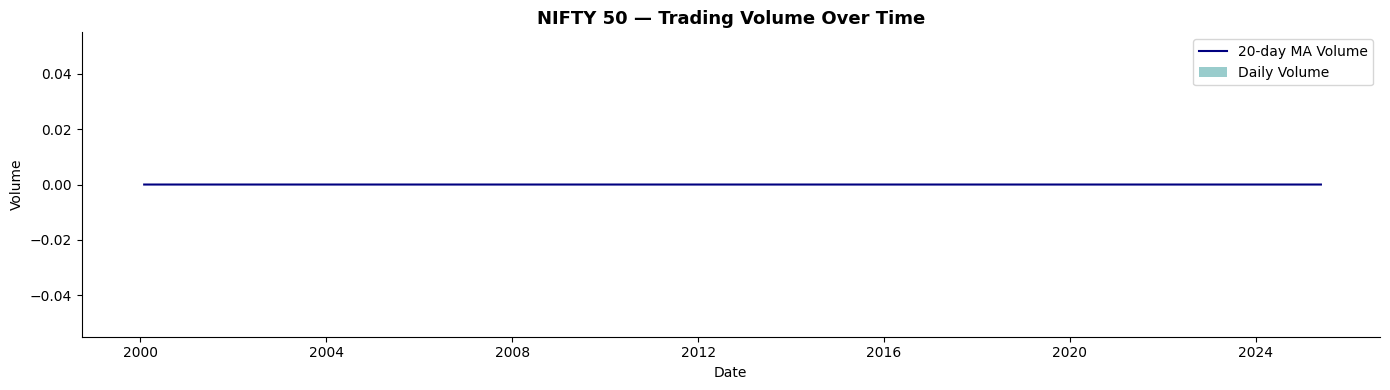

In [75]:
# Standardize all column names
df.columns = df.columns.str.strip()  # remove spaces
print("Columns found:", df.columns.tolist())

# Rename if your volume column has a different name
# Example: if it's called 'Shares Traded', rename it:
df.rename(columns={
    'Shares Traded': 'Volume',   # change left side to match your actual column name
    'Turnover' : 'Volume'        # only one of these lines will apply
}, inplace=True)

print("Columns after rename:", df.columns.tolist())

# Add a dummy Volume column since your CSV doesn't have it
df['Volume'] = 0

print("✅ Fixed. Columns now:", df.columns.tolist())

feature_cols = [
    'Open', 'High', 'Low', 'Close',
    'MA_7', 'MA_14', 'MA_30',
    'Close_MA7_Ratio', 'Close_MA14_Ratio', 'Close_MA30_Ratio',
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag7',
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag7',
    'Daily_Return', 'Volatility_21',
    'HL_Spread', 'OC_Body', 'Price_Range_Pct',
    'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width', 'BB_Pct',
    'Day_of_Week', 'Day_of_Month', 'Month_Num', 'Quarter', 'Year'
]

print(f"✅ Feature list updated. Using {len(feature_cols)} features (Volume features removed).")

# ─── 2.5 VOLUME TREND ────────────────────────────────────────────────────────
df['Volume_MA20'] = df['Volume'].rolling(20).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df['Date'], df['Volume'], color='teal', alpha=0.4, width=1, label='Daily Volume')
ax.plot(df['Date'], df['Volume_MA20'], color='navy', linewidth=1.5, label='20-day MA Volume')
ax.set_title('NIFTY 50 — Trading Volume Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volume')
ax.legend()
plt.tight_layout()
plt.show()

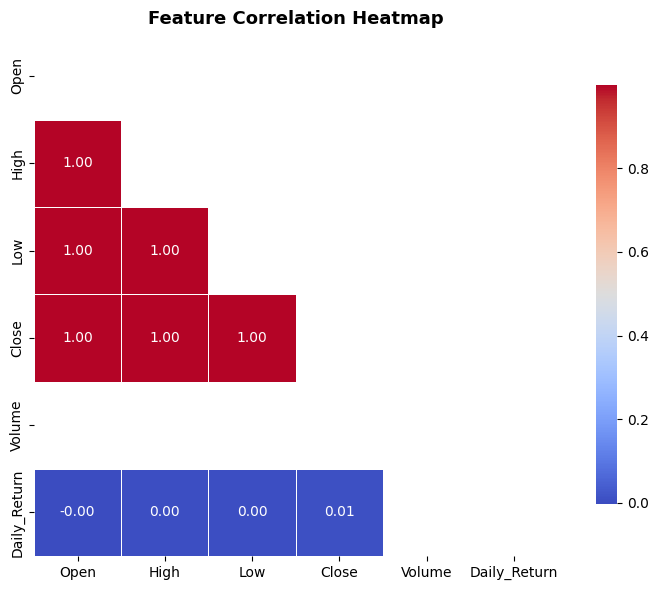

Open, High, Low, Close are highly correlated — expected for OHLC data.
Volume and returns show lower correlation with price levels.


In [76]:
# ─── 2.6 CORRELATION HEATMAP ─────────────────────────────────────────────────
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Open, High, Low, Close are highly correlated — expected for OHLC data.')
print('Volume and returns show lower correlation with price levels.')

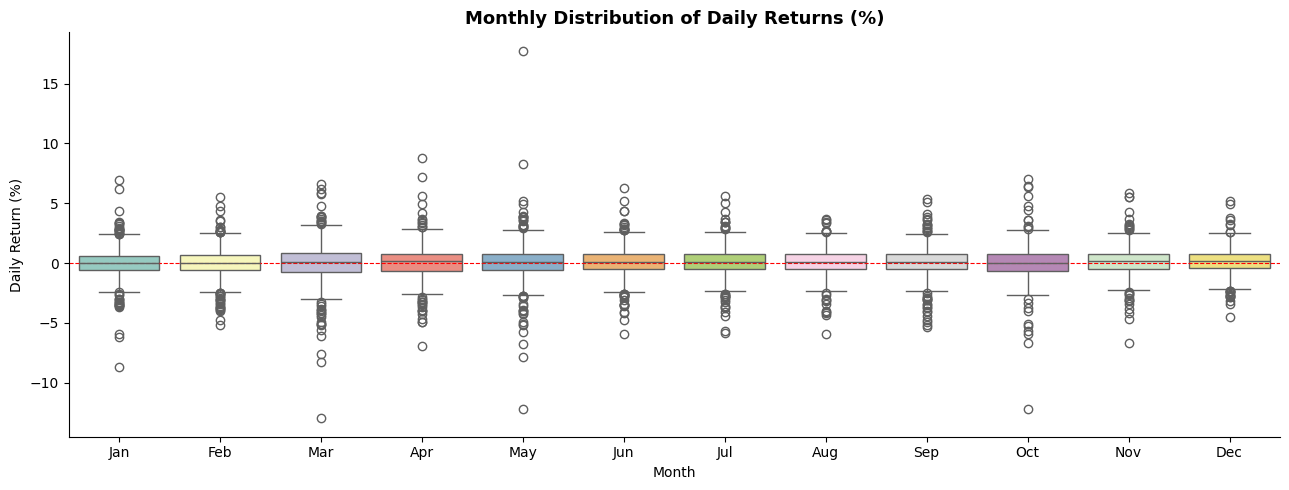

Box plots reveal seasonal patterns and months with higher variability in returns.


In [77]:
# ─── 2.7 BOX PLOT — MONTHLY RETURNS ─────────────────────────────────────────
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

fig, ax = plt.subplots(figsize=(13, 5))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(
    data=df.dropna(subset=['Daily_Return']),
    x='Month_Name', y='Daily_Return',
    order=month_order, palette='Set3', ax=ax
)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Monthly Distribution of Daily Returns (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

print('Box plots reveal seasonal patterns and months with higher variability in returns.')

---
# SECTION 3: Feature Engineering
---
We create meaningful features from raw OHLCV data:
- **Moving Averages** — MA7, MA14, MA30 (trend signals)
- **Lag Features** — past closing prices (autocorrelation signals)
- **Technical Indicators** — RSI, MACD, Bollinger Bands
- **Time Features** — day, month, year
- **Two Target Variables** — next-day close (regression) and direction (classification)

In [78]:
# ─── 3.1 MOVING AVERAGES ─────────────────────────────────────────────────────
df['MA_7']  = df['Close'].rolling(7).mean()
df['MA_14'] = df['Close'].rolling(14).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

# MA ratios (close relative to MA — more informative than raw MA)
df['Close_MA7_Ratio']  = df['Close'] / df['MA_7']
df['Close_MA14_Ratio'] = df['Close'] / df['MA_14']
df['Close_MA30_Ratio'] = df['Close'] / df['MA_30']

print('✅ Moving averages and ratios created.')

✅ Moving averages and ratios created.


In [79]:
# ─── 3.2 LAG FEATURES ────────────────────────────────────────────────────────
for lag in [1, 2, 3, 7]:
    df[f'Close_Lag{lag}'] = df['Close'].shift(lag)
    df[f'Return_Lag{lag}'] = df['Daily_Return'].shift(lag)

print('✅ Lag features created for periods: 1, 2, 3, 7 days.')

✅ Lag features created for periods: 1, 2, 3, 7 days.


In [80]:
# ─── 3.3 TECHNICAL INDICATORS ────────────────────────────────────────────────

# High-Low spread and Open-Close body
df['HL_Spread']  = df['High'] - df['Low']
df['OC_Body']    = df['Close'] - df['Open']
df['Price_Range_Pct'] = df['HL_Spread'] / df['Close'] * 100

# RSI (14-period)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'])

# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# Bollinger Bands (20-period)
rolling_mean = df['Close'].rolling(20).mean()
rolling_std  = df['Close'].rolling(20).std()
df['BB_Upper'] = rolling_mean + 2 * rolling_std
df['BB_Lower'] = rolling_mean - 2 * rolling_std
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
df['BB_Pct']   = (df['Close'] - df['BB_Lower']) / df['BB_Width']  # 0–1 position in band

# Volume features
df['Volume_Change'] = df['Volume'].pct_change() * 100
df['Volume_MA5']    = df['Volume'].rolling(5).mean()
df['Volume_Ratio']  = df['Volume'] / df['Volume_MA5']

print('✅ Technical indicators computed: RSI, MACD, Bollinger Bands, Volume features.')

✅ Technical indicators computed: RSI, MACD, Bollinger Bands, Volume features.


In [81]:
# ─── 3.4 TIME FEATURES ───────────────────────────────────────────────────────
df['Day_of_Week'] = df['Date'].dt.dayofweek    # 0=Mon, 4=Fri
df['Day_of_Month']= df['Date'].dt.day
df['Month_Num']   = df['Date'].dt.month
df['Quarter']     = df['Date'].dt.quarter
df['Year']        = df['Date'].dt.year

print('✅ Calendar features created.')

✅ Calendar features created.


Target created successfully.
UP days   (1): 3406  (53.9%)
DOWN days (0): 2908 (46.1%)


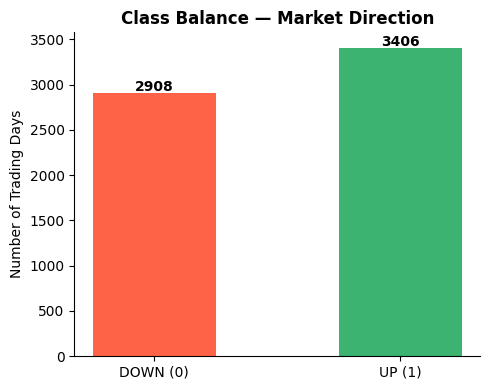

In [82]:
# ─── 3.5 TARGET VARIABLES ────────────────────────────────────────────────────

# Target 1: Next day closing price (Regression)
df['next_day_close'] = df['Close'].shift(-1)

# Target 2: Market direction (Classification)
# 1 = UP (next day close > today close), 0 = DOWN
df['direction'] = (df['next_day_close'] > df['Close']).astype(int)

# Drop the last row (no next-day target)
df.dropna(subset=['next_day_close'], inplace=True)

# Class balance
up_days   = df['direction'].sum()
down_days = len(df) - up_days
print(f'Target created successfully.')
print(f'UP days   (1): {up_days}  ({up_days/len(df)*100:.1f}%)')
print(f'DOWN days (0): {down_days} ({down_days/len(df)*100:.1f}%)')

# Visualize class balance
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['DOWN (0)', 'UP (1)'], [down_days, up_days], color=['tomato', 'mediumseagreen'], width=0.5)
ax.set_title('Class Balance — Market Direction', fontweight='bold')
ax.set_ylabel('Number of Trading Days')
for i, v in enumerate([down_days, up_days]):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
# SECTION 4: Preprocessing
---
### Why NOT random train-test split?
In time series data, future values are **causally dependent** on past values. A random split would allow the model to "see" future data during training (data leakage), resulting in **artificially inflated performance metrics** that would not hold in real deployment. We instead use a **chronological (time-based) split** — training on earlier data and testing on the most recent portion.

In [83]:
# ─── 4.1 DEFINE FEATURES ─────────────────────────────────────────────────────
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'MA_7', 'MA_14', 'MA_30',
    'Close_MA7_Ratio', 'Close_MA14_Ratio', 'Close_MA30_Ratio',
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag7',
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag7',
    'Daily_Return', 'Volatility_21',
    'HL_Spread', 'OC_Body', 'Price_Range_Pct',
    'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width', 'BB_Pct',
    'Volume_Change', 'Volume_Ratio',
    'Day_of_Week', 'Day_of_Month', 'Month_Num', 'Quarter', 'Year'
]

# Drop rows with any NaN in features or targets
df_clean = df.dropna(subset=feature_cols + ['next_day_close', 'direction']).copy()
df_clean.reset_index(drop=True, inplace=True)

print(f'Clean dataset size: {len(df_clean)} rows')
print(f'Number of features: {len(feature_cols)}')

# ═══ COMPLETE FEATURE ENGINEERING — run this if Section 3 was skipped ═══

# Moving averages
df['MA_7']  = df['Close'].rolling(7).mean()
df['MA_14'] = df['Close'].rolling(14).mean()
df['MA_30'] = df['Close'].rolling(30).mean()
df['Close_MA7_Ratio']  = df['Close'] / df['MA_7']
df['Close_MA14_Ratio'] = df['Close'] / df['MA_14']
df['Close_MA30_Ratio'] = df['Close'] / df['MA_30']

# Lag features
for lag in [1, 2, 3, 7]:
    df[f'Close_Lag{lag}']  = df['Close'].shift(lag)
    df[f'Return_Lag{lag}'] = df['Daily_Return'].shift(lag)

# Price features
df['HL_Spread']       = df['High'] - df['Low']
df['OC_Body']         = df['Close'] - df['Open']
df['Price_Range_Pct'] = df['HL_Spread'] / df['Close'] * 100

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))
df['RSI_14'] = compute_rsi(df['Close'])

# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# Bollinger Bands
rolling_mean   = df['Close'].rolling(20).mean()
rolling_std    = df['Close'].rolling(20).std()
df['BB_Upper'] = rolling_mean + 2 * rolling_std
df['BB_Lower'] = rolling_mean - 2 * rolling_std
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
df['BB_Pct']   = (df['Close'] - df['BB_Lower']) / df['BB_Width']

# Time features
df['Day_of_Week']  = df['Date'].dt.dayofweek
df['Day_of_Month'] = df['Date'].dt.day
df['Month_Num']    = df['Date'].dt.month
df['Quarter']      = df['Date'].dt.quarter
df['Year']         = df['Date'].dt.year

# Targets
df['next_day_close'] = df['Close'].shift(-1)
df['direction']      = (df['next_day_close'] > df['Close']).astype(int)
df.dropna(subset=['next_day_close'], inplace=True)

# Feature list (no Volume)
feature_cols = [
    'Open', 'High', 'Low', 'Close',
    'MA_7', 'MA_14', 'MA_30',
    'Close_MA7_Ratio', 'Close_MA14_Ratio', 'Close_MA30_Ratio',
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag7',
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag7',
    'Daily_Return', 'Volatility_21',
    'HL_Spread', 'OC_Body', 'Price_Range_Pct',
    'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width', 'BB_Pct',
    'Day_of_Week', 'Day_of_Month', 'Month_Num', 'Quarter', 'Year'
]

# Clean dataset
df_clean = df.dropna(subset=feature_cols + ['next_day_close', 'direction']).copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"✅ Features built successfully.")
print(f"df_clean shape : {df_clean.shape}")
print(f"Features used  : {len(feature_cols)}")

Clean dataset size: 0 rows
Number of features: 37
✅ Features built successfully.
df_clean shape : (6284, 49)
Features used  : 34


Training set : 5027 rows  (2000-02-14 → 2020-04-30)
Test set     : 1257 rows  (2020-05-04 → 2025-05-22)


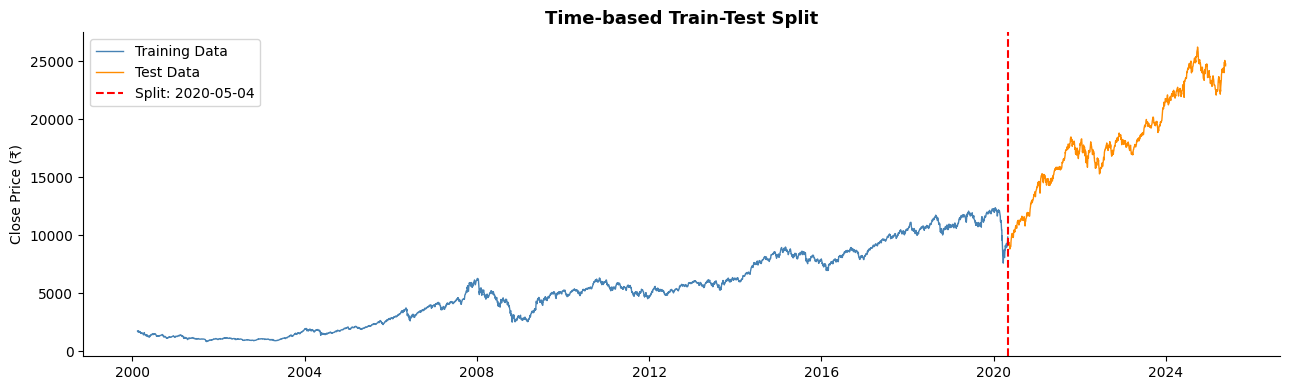

In [84]:
# ─── 4.2 TIME-BASED TRAIN-TEST SPLIT (80/20) ──────────────────────────────────
split_idx = int(len(df_clean) * 0.80)
split_date = df_clean.iloc[split_idx]['Date']

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]

print(f'Training set : {len(train_df)} rows  ({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test set     : {len(test_df)} rows  ({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')

# Visualize the split
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df['Date'], train_df['Close'], color='steelblue',  label='Training Data', linewidth=1)
ax.plot(test_df['Date'],  test_df['Close'],  color='darkorange', label='Test Data',     linewidth=1)
ax.axvline(split_date, color='red', linestyle='--', linewidth=1.5, label=f'Split: {split_date.date()}')
ax.set_title('Time-based Train-Test Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Close Price (₹)')
ax.legend()
plt.tight_layout()
plt.show()

In [85]:
# ─── 4.3 FEATURE-TARGET SEPARATION & SCALING ──────────────────────────────────
X_train_raw = train_df[feature_cols].values
X_test_raw  = test_df[feature_cols].values

# Regression targets
y_train_reg = train_df['next_day_close'].values
y_test_reg  = test_df['next_day_close'].values

# Classification targets
y_train_cls = train_df['direction'].values
y_test_cls  = test_df['direction'].values

# Standard Scaling (fit on train only — avoids data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print('✅ Features scaled using StandardScaler (fit on train only).')
print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

✅ Features scaled using StandardScaler (fit on train only).
X_train shape: (5027, 34)
X_test  shape: (1257, 34)


---
# SECTION 5: Regression Models
---
We train 5 regression models to predict the next day's closing price.

In [86]:
# ─── 5.0 REGRESSION HELPER ────────────────────────────────────────────────────
reg_results = {}

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Predictions': preds, 'Model': model}
    print(f'{name:30s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R²: {r2:.4f}')
    return preds

print(f'{"Model":<30} | {"MAE":>10} | {"RMSE":>10} | {"R²":>8}')
print('─' * 65)

Model                          |        MAE |       RMSE |       R²
─────────────────────────────────────────────────────────────────


In [87]:
# ─── 5.1 LINEAR REGRESSION ───────────────────────────────────────────────────
lr = LinearRegression()
evaluate_regressor('Linear Regression', lr, X_train, y_train_reg, X_test, y_test_reg)

Linear Regression              | MAE:   129.88 | RMSE:   175.94 | R²: 0.9981


array([ 9292.41394636,  9181.77084854,  9252.8424896 , ...,
       24623.65685596, 24744.30315082, 24552.52473094])

In [88]:
# ─── 5.2 DECISION TREE REGRESSOR ─────────────────────────────────────────────
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
evaluate_regressor('Decision Tree Regressor', dt_reg, X_train, y_train_reg, X_test, y_test_reg)

Decision Tree Regressor        | MAE:  6123.54 | RMSE:  7183.70 | R²: -2.1495


array([ 9335.28181818,  9150.235     ,  9224.75      , ...,
       12294.33      , 12294.33      , 12294.33      ])

In [89]:
# ─── 5.3 RANDOM FOREST REGRESSOR ─────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
evaluate_regressor('Random Forest Regressor', rf_reg, X_train, y_train_reg, X_test, y_test_reg)

Random Forest Regressor        | MAE:  6186.97 | RMSE:  7246.08 | R²: -2.2044


array([ 9447.53664589,  9200.01169427,  9215.79912429, ...,
       12220.45682432, 12233.95996782, 12208.9276667 ])

In [90]:
# ─── 5.4 XGBOOST REGRESSOR ───────────────────────────────────────────────────
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, verbosity=0)
evaluate_regressor('XGBoost Regressor', xgb_reg, X_train, y_train_reg, X_test, y_test_reg)

XGBoost Regressor              | MAE:  6269.60 | RMSE:  7323.86 | R²: -2.2736


array([ 9304.806 ,  9231.1875,  9263.52  , ..., 12061.316 , 12122.517 ,
       12083.622 ], dtype=float32)

In [91]:
# ─── 5.5 SVR ─────────────────────────────────────────────────────────────────
svr = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
evaluate_regressor('SVR', svr, X_train, y_train_reg, X_test, y_test_reg)

SVR                            | MAE: 11272.48 | RMSE: 12600.79 | R²: -8.6903


array([5803.66630537, 6130.38767222, 6734.30541104, ..., 4993.39461626,
       5003.28222949, 5008.33890301])

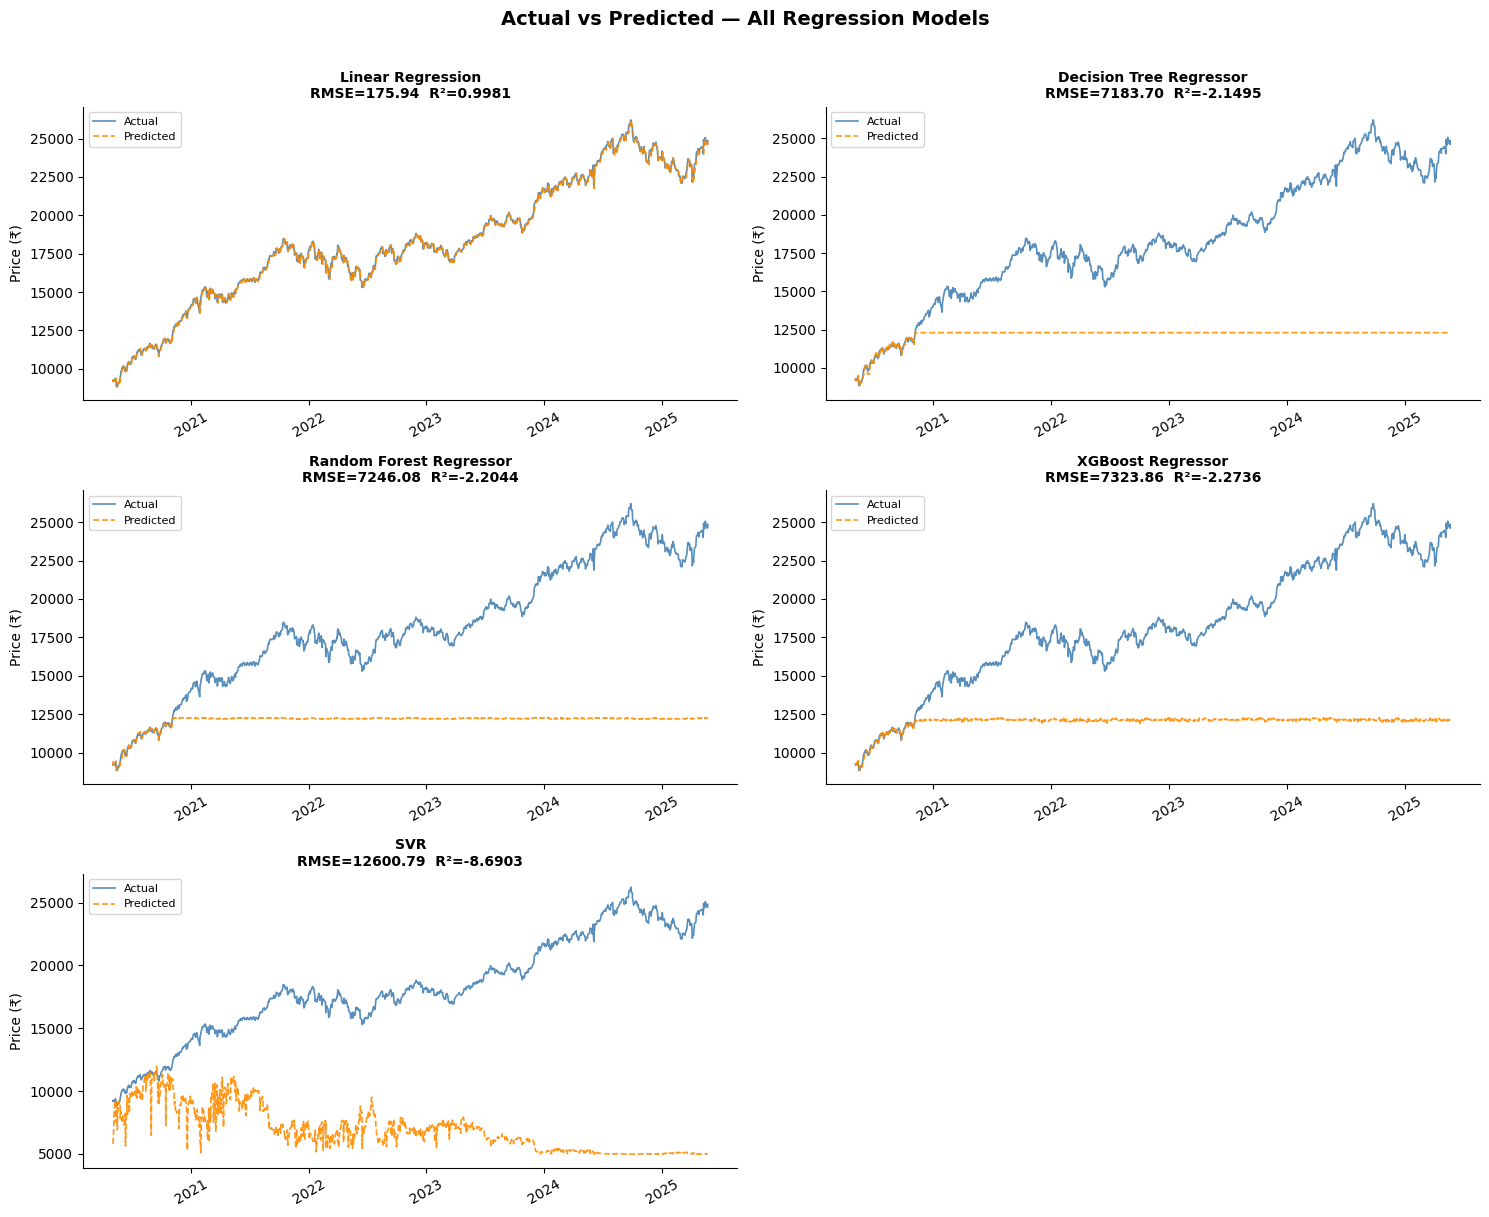

In [92]:
# ─── 5.6 REGRESSION — ACTUAL VS PREDICTED (ALL MODELS) ───────────────────────
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
test_dates = test_df['Date'].values

for i, (name, res) in enumerate(reg_results.items()):
    ax = axes[i]
    ax.plot(test_dates, y_test_reg,    color='steelblue',  linewidth=1.2, label='Actual',    alpha=0.9)
    ax.plot(test_dates, res['Predictions'], color='darkorange', linewidth=1.2, label='Predicted', alpha=0.9, linestyle='--')
    ax.set_title(f'{name}\nRMSE={res["RMSE"]:.2f}  R²={res["R2"]:.4f}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
fig.suptitle('Actual vs Predicted — All Regression Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

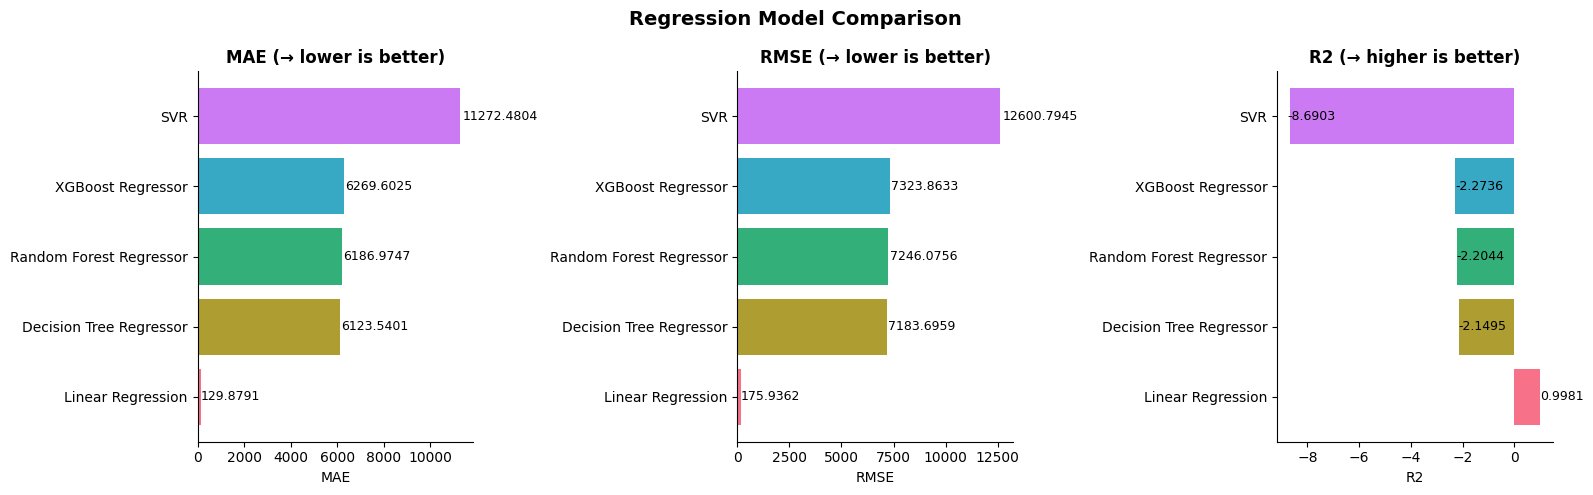

,MAE,RMSE,R2
Model,,,
Linear Regression,129.8791,175.9362,0.9981
Decision Tree Regressor,6123.5401,7183.6959,-2.1495
Random Forest Regressor,6186.9747,7246.0756,-2.2044
XGBoost Regressor,6269.6025,7323.8633,-2.2736
SVR,11272.4804,12600.7945,-8.6903


In [93]:
# ─── 5.7 REGRESSION MODEL COMPARISON CHART ───────────────────────────────────
reg_comparison = pd.DataFrame({
    'Model': list(reg_results.keys()),
    'MAE':   [v['MAE']  for v in reg_results.values()],
    'RMSE':  [v['RMSE'] for v in reg_results.values()],
    'R2':    [v['R2']   for v in reg_results.values()]
}).sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = sns.color_palette('husl', len(reg_comparison))

for ax, metric, better in zip(axes, ['MAE', 'RMSE', 'R2'], ['lower', 'lower', 'higher']):
    bars = ax.barh(reg_comparison['Model'], reg_comparison[metric], color=colors)
    ax.set_title(f'{metric} (→ {better} is better)', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, reg_comparison[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(reg_comparison.set_index('Model').round(4))

---
# SECTION 6: Classification Models
---
We train 5 classification models to predict whether the market will go UP (1) or DOWN (0) next day.

In [94]:
# ─── 6.0 CLASSIFICATION HELPER ────────────────────────────────────────────────
cls_results = {}

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    # Probability for ROC curve
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.decision_function(X_te)
        proba = (proba - proba.min()) / (proba.max() - proba.min())  # normalize
    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, zero_division=0)
    rec  = recall_score(y_te, preds, zero_division=0)
    f1   = f1_score(y_te, preds, zero_division=0)
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_score   = auc(fpr, tpr)
    cls_results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'AUC': auc_score, 'Predictions': preds, 'Probas': proba,
        'FPR': fpr, 'TPR': tpr, 'Model': model
    }
    print(f'{name:30s} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}')
    return preds

print(f'{"Model":<30} | {"Acc":>8} | {"Prec":>8} | {"Rec":>8} | {"F1":>8} | {"AUC":>8}')
print('─' * 80)

Model                          |      Acc |     Prec |      Rec |       F1 |      AUC
────────────────────────────────────────────────────────────────────────────────


In [95]:
# ─── 6.1 LOGISTIC REGRESSION ─────────────────────────────────────────────────
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
evaluate_classifier('Logistic Regression', log_reg, X_train, y_train_cls, X_test, y_test_cls)

Logistic Regression            | Acc: 0.4678 | Prec: 0.6556 | Rec: 0.0846 | F1: 0.1499 | AUC: 0.5480


array([0, 1, 0, ..., 0, 0, 0])

In [96]:
# ─── 6.2 DECISION TREE CLASSIFIER ────────────────────────────────────────────
dt_cls = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
evaluate_classifier('Decision Tree Classifier', dt_cls, X_train, y_train_cls, X_test, y_test_cls)

Decision Tree Classifier       | Acc: 0.5155 | Prec: 0.6170 | Rec: 0.3329 | F1: 0.4324 | AUC: 0.5294


array([1, 0, 0, ..., 0, 1, 1])

In [97]:

# ─── CLASSIFICATION HELPER FUNCTION ──────────────────────────────────────────
cls_results = {}

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.decision_function(X_te)
        proba = (proba - proba.min()) / (proba.max() - proba.min())
    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, zero_division=0)
    rec  = recall_score(y_te, preds, zero_division=0)
    f1   = f1_score(y_te, preds, zero_division=0)
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_score   = auc(fpr, tpr)
    cls_results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'AUC': auc_score, 'Predictions': preds, 'Probas': proba,
        'FPR': fpr, 'TPR': tpr, 'Model': model
    }
    print(f'{name:30s} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}')
    return preds

print(f'{"Model":<30} | {"Acc":>8} | {"Prec":>8} | {"Rec":>8} | {"F1":>8} | {"AUC":>8}')
print('─' * 80)
print('✅ evaluate_classifier function ready.')

# ─── 6.3 RANDOM FOREST CLASSIFIER ────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1)
evaluate_classifier('Random Forest Classifier', rf_cls, X_train, y_train_cls, X_test, y_test_cls)

Model                          |      Acc |     Prec |      Rec |       F1 |      AUC
────────────────────────────────────────────────────────────────────────────────
✅ evaluate_classifier function ready.
Random Forest Classifier       | Acc: 0.4654 | Prec: 0.6263 | Rec: 0.0890 | F1: 0.1558 | AUC: 0.5009


array([1, 0, 0, ..., 0, 0, 0])

In [98]:
# ─── 6.4 XGBOOST CLASSIFIER ──────────────────────────────────────────────────
xgb_cls = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         use_label_encoder=False, eval_metric='logloss',
                         random_state=42, verbosity=0)
evaluate_classifier('XGBoost Classifier', xgb_cls, X_train, y_train_cls, X_test, y_test_cls)

XGBoost Classifier             | Acc: 0.4948 | Prec: 0.5876 | Rec: 0.2984 | F1: 0.3958 | AUC: 0.5304


array([1, 1, 0, ..., 0, 0, 0])

In [99]:
# ─── 6.5 SVM CLASSIFIER ──────────────────────────────────────────────────────
svm_cls = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
evaluate_classifier('SVM Classifier', svm_cls, X_train, y_train_cls, X_test, y_test_cls)

SVM Classifier                 | Acc: 0.4885 | Prec: 0.5504 | Rec: 0.4232 | F1: 0.4785 | AUC: 0.5036


array([1, 1, 1, ..., 1, 1, 1])

---
# SECTION 7: Evaluation
---
## 7A — Regression Evaluation
## 7B — Classification Evaluation
### ⭐ Special emphasis on ROC Curves and AUC Scores

In [100]:
# ─── 7A.1 REGRESSION SUMMARY TABLE ───────────────────────────────────────────
print('=== Regression Model Performance Summary ===')
reg_summary = pd.DataFrame({
    'Model': list(reg_results.keys()),
    'MAE':   [round(v['MAE'], 2)  for v in reg_results.values()],
    'RMSE':  [round(v['RMSE'], 2) for v in reg_results.values()],
    'R²':    [round(v['R2'], 4)   for v in reg_results.values()]
}).sort_values('R²', ascending=False)
display(reg_summary.set_index('Model'))

best_reg = reg_summary.iloc[0]['Model']
print(f'\n🏆 Best Regression Model: {best_reg} (R² = {reg_summary.iloc[0]["R²"]})')

=== Regression Model Performance Summary ===


,MAE,RMSE,R²
Model,,,
Linear Regression,129.88,175.94,0.9981
Decision Tree Regressor,6123.54,7183.70,-2.1495
Random Forest Regressor,6186.97,7246.08,-2.2044
XGBoost Regressor,6269.60,7323.86,-2.2736
SVR,11272.48,12600.79,-8.6903



🏆 Best Regression Model: Linear Regression (R² = 0.9981)


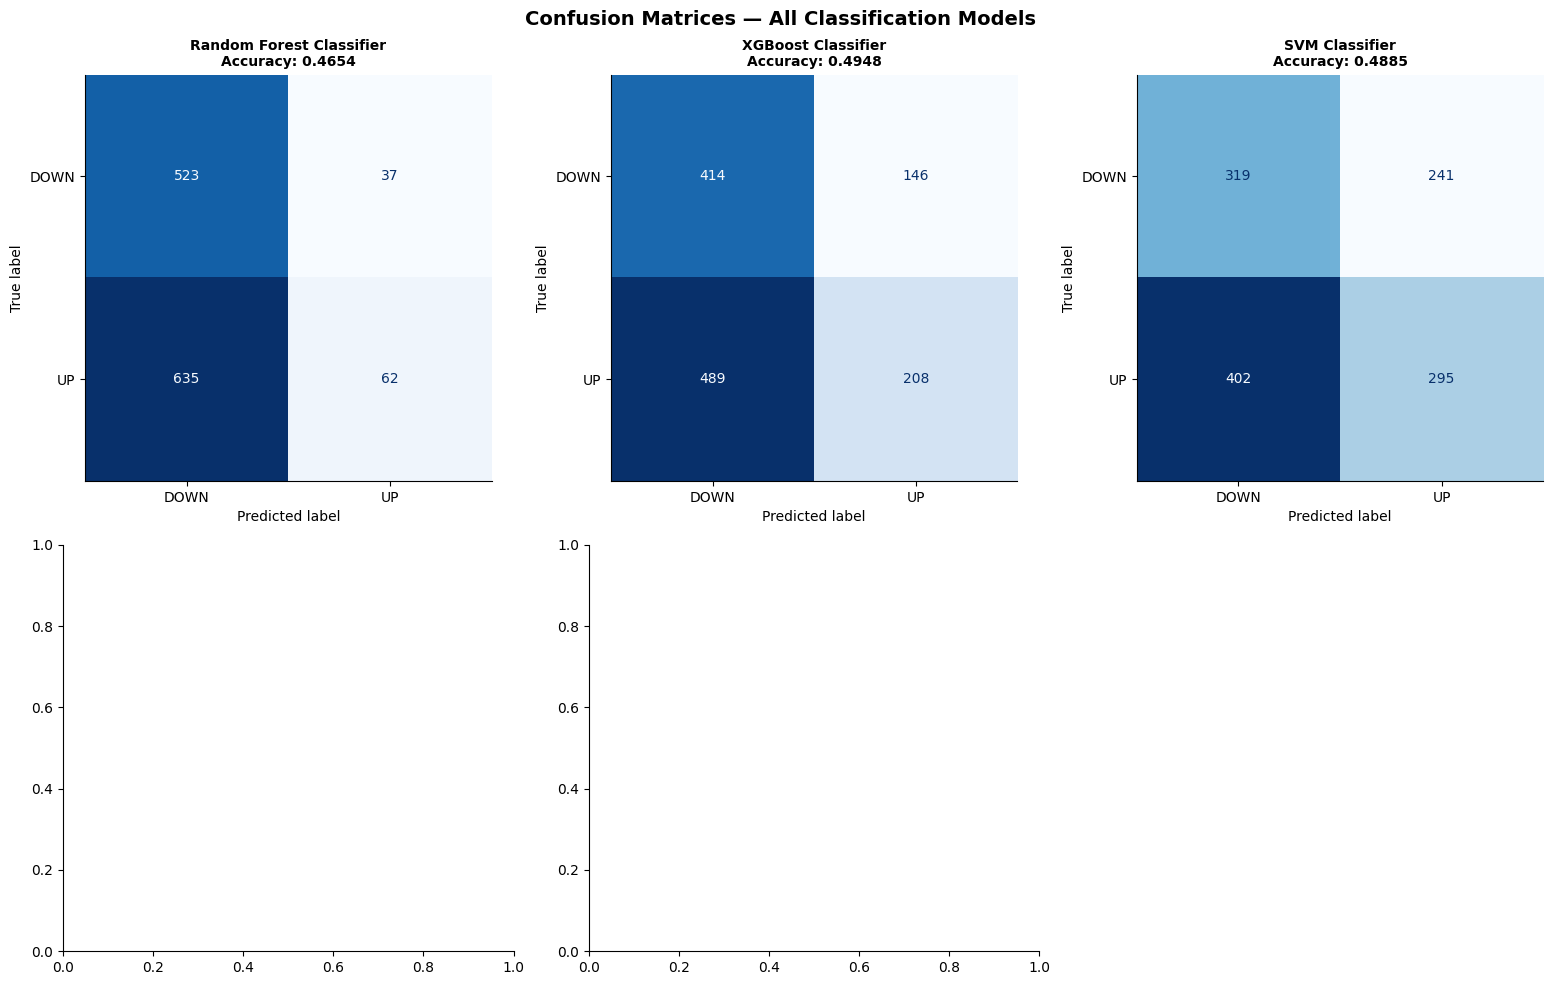

Confusion Matrix Interpretation:
  True Negative  (TN): Correctly predicted DOWN
  False Positive (FP): Predicted UP but was DOWN (Type I error)
  False Negative (FN): Predicted DOWN but was UP (Type II error)
  True Positive  (TP): Correctly predicted UP


In [101]:
# ─── 7B.1 CONFUSION MATRICES — ALL CLASSIFIERS ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(cls_results.items()):
    cm = confusion_matrix(y_test_cls, res['Predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAccuracy: {res["Accuracy"]:.4f}', fontsize=10, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Confusion Matrices — All Classification Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Confusion Matrix Interpretation:')
print('  True Negative  (TN): Correctly predicted DOWN')
print('  False Positive (FP): Predicted UP but was DOWN (Type I error)')
print('  False Negative (FN): Predicted DOWN but was UP (Type II error)')
print('  True Positive  (TP): Correctly predicted UP')

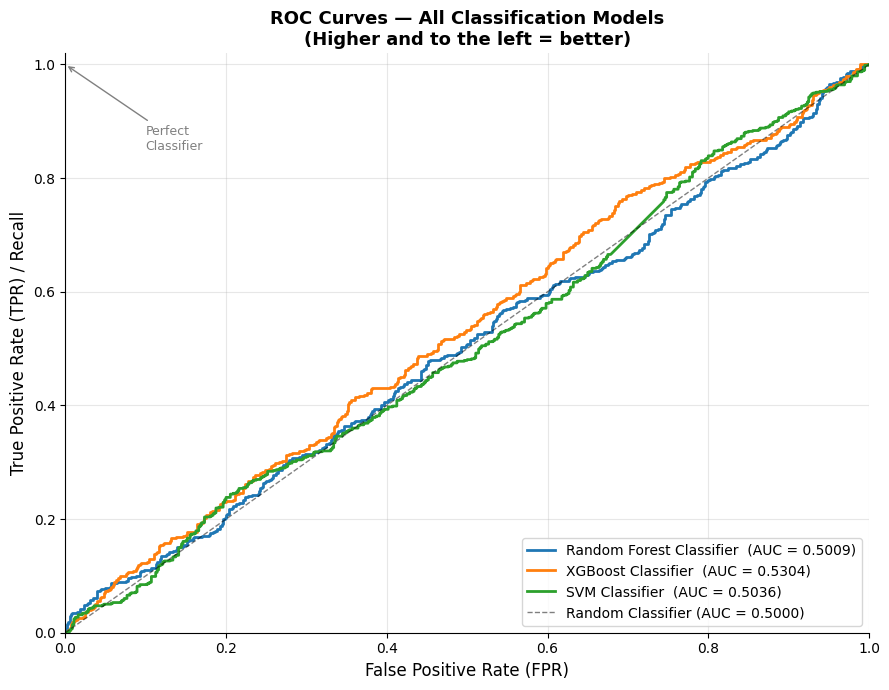


AUC Scores (ranked):
  XGBoost Classifier            : 0.5304
  SVM Classifier                : 0.5036
  Random Forest Classifier      : 0.5009


In [102]:
# ─── 7B.2 ⭐ ROC CURVES — ALL MODELS IN ONE GRAPH ─────────────────────────────
#
# ROC Curve explanation:
# - X-axis: False Positive Rate (FPR) = FP / (FP + TN)  → "How often we cry wolf"
# - Y-axis: True  Positive Rate (TPR) = TP / (TP + FN)  → "How well we catch UP days"
# - AUC = Area Under Curve. AUC=1.0 → perfect; AUC=0.5 → random guessing (diagonal line)
# - Higher AUC = better model discriminability between UP and DOWN days

fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, res), color in zip(cls_results.items(), colors_roc):
    ax.plot(res['FPR'], res['TPR'],
            color=color, linewidth=2,
            label=f'{name}  (AUC = {res["AUC"]:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)', alpha=0.5)

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR) / Recall', fontsize=12)
ax.set_title('ROC Curves — All Classification Models\n(Higher and to the left = better)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

# Annotate perfect point
ax.annotate('Perfect\nClassifier', xy=(0, 1), xytext=(0.1, 0.85),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC Scores (ranked):')
auc_df = pd.DataFrame({
    'Model': list(cls_results.keys()),
    'AUC': [v['AUC'] for v in cls_results.values()]
}).sort_values('AUC', ascending=False)
for _, row in auc_df.iterrows():
    print(f'  {row["Model"]:30s}: {row["AUC"]:.4f}')

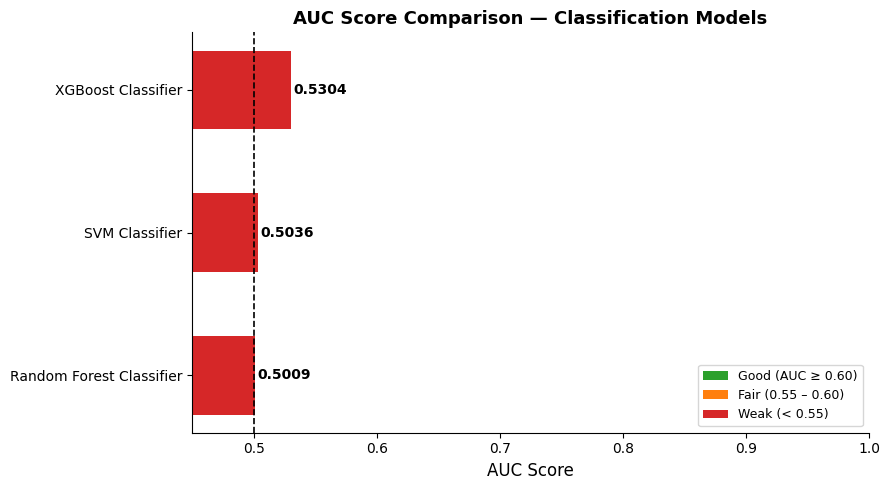

In [103]:
# ─── 7B.3 ⭐ AUC SCORE COMPARISON BAR CHART ───────────────────────────────────
auc_df_sorted = auc_df.sort_values('AUC', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#d62728' if v < 0.55 else '#ff7f0e' if v < 0.60 else '#2ca02c'
              for v in auc_df_sorted['AUC']]
bars = ax.barh(auc_df_sorted['Model'], auc_df_sorted['AUC'], color=bar_colors, height=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Random (AUC=0.5)')
ax.set_xlim(0.45, 1.0)
ax.set_xlabel('AUC Score', fontsize=12)
ax.set_title('AUC Score Comparison — Classification Models', fontsize=13, fontweight='bold')
ax.legend()

for bar, val in zip(bars, auc_df_sorted['AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='Good (AUC ≥ 0.60)'),
                   Patch(facecolor='#ff7f0e', label='Fair (0.55 – 0.60)'),
                   Patch(facecolor='#d62728', label='Weak (< 0.55)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

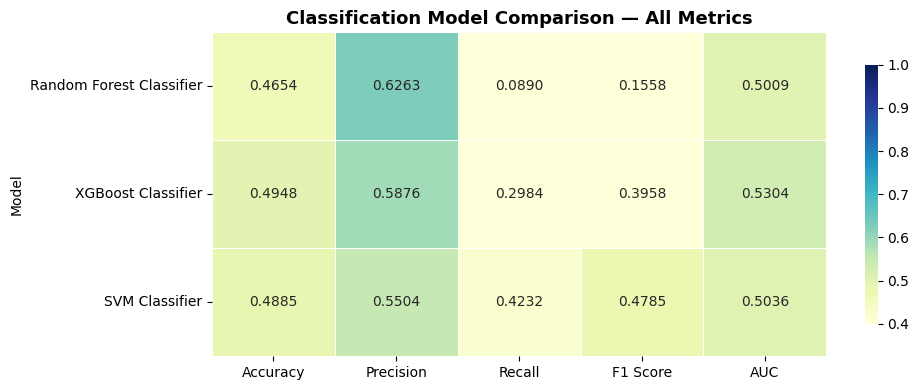


Full Classification Report — All Models:

--- Random Forest Classifier ---
              precision    recall  f1-score   support

        DOWN       0.45      0.93      0.61       560
          UP       0.63      0.09      0.16       697

    accuracy                           0.47      1257
   macro avg       0.54      0.51      0.38      1257
weighted avg       0.55      0.47      0.36      1257


--- XGBoost Classifier ---
              precision    recall  f1-score   support

        DOWN       0.46      0.74      0.57       560
          UP       0.59      0.30      0.40       697

    accuracy                           0.49      1257
   macro avg       0.52      0.52      0.48      1257
weighted avg       0.53      0.49      0.47      1257


--- SVM Classifier ---
              precision    recall  f1-score   support

        DOWN       0.44      0.57      0.50       560
          UP       0.55      0.42      0.48       697

    accuracy                           0.49      1257


In [104]:
# ─── 7B.4 CLASSIFICATION METRICS COMPARISON (HEATMAP) ────────────────────────
cls_summary = pd.DataFrame({
    'Model':     list(cls_results.keys()),
    'Accuracy':  [round(v['Accuracy'],  4) for v in cls_results.values()],
    'Precision': [round(v['Precision'], 4) for v in cls_results.values()],
    'Recall':    [round(v['Recall'],    4) for v in cls_results.values()],
    'F1 Score':  [round(v['F1'],        4) for v in cls_results.values()],
    'AUC':       [round(v['AUC'],       4) for v in cls_results.values()]
}).set_index('Model')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cls_summary, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            vmin=0.4, vmax=1.0)
ax.set_title('Classification Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFull Classification Report — All Models:')
for name, res in cls_results.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test_cls, res['Predictions'], target_names=['DOWN', 'UP']))

Best Classification Model: XGBoost Classifier
AUC Score: 0.5304


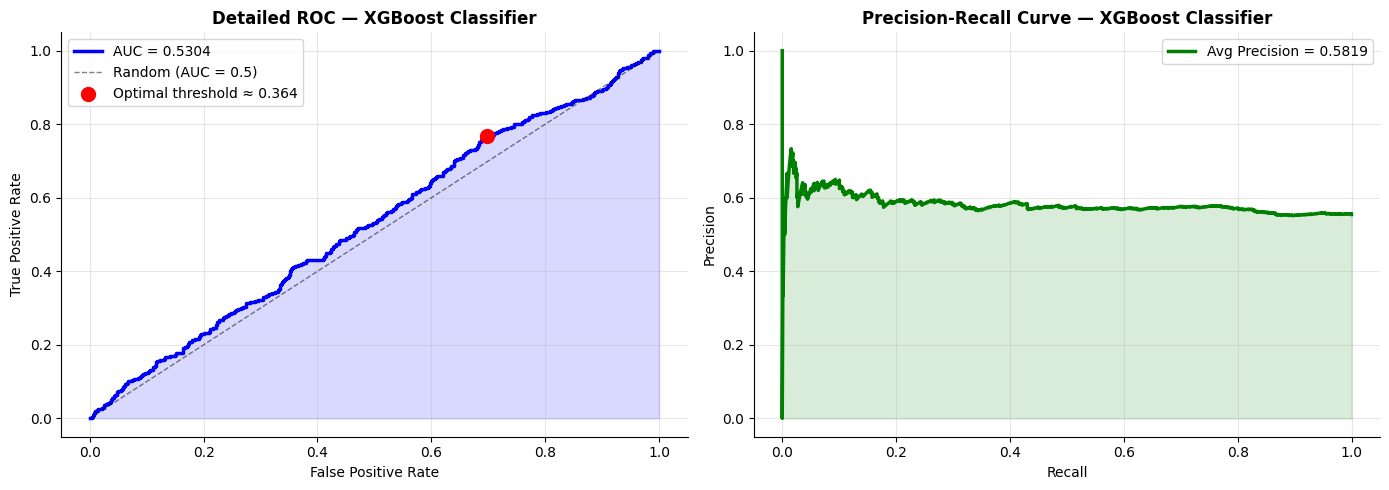


Optimal operating point (Youden's J):
  Threshold ≈ 0.3644
  TPR       = 0.7690  (sensitivity/recall)
  FPR       = 0.6982  (1 - specificity)


In [105]:
# ─── 7B.5 BEST CLASSIFICATION MODEL — DETAILED ROC ───────────────────────────
best_cls_name = auc_df.iloc[0]['Model']
best_cls_res  = cls_results[best_cls_name]

print(f'Best Classification Model: {best_cls_name}')
print(f'AUC Score: {best_cls_res["AUC"]:.4f}')

# Find optimal threshold (Youden's J statistic: max TPR - FPR)
j_scores = best_cls_res['TPR'] - best_cls_res['FPR']
optimal_idx = np.argmax(j_scores)
# Get the threshold at optimal index
_, _, thresholds = roc_curve(y_test_cls, best_cls_res['Probas'])
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
opt_fpr = best_cls_res['FPR'][optimal_idx]
opt_tpr = best_cls_res['TPR'][optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Detailed ROC
ax = axes[0]
ax.fill_between(best_cls_res['FPR'], best_cls_res['TPR'], alpha=0.15, color='blue')
ax.plot(best_cls_res['FPR'], best_cls_res['TPR'], color='blue', linewidth=2.5,
        label=f'AUC = {best_cls_res["AUC"]:.4f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.scatter([opt_fpr], [opt_tpr], s=100, color='red', zorder=5,
           label=f'Optimal threshold ≈ {optimal_threshold:.3f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Detailed ROC — {best_cls_name}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
prec_vals, rec_vals, _ = precision_recall_curve(y_test_cls, best_cls_res['Probas'])
ap_score = average_precision_score(y_test_cls, best_cls_res['Probas'])

ax2 = axes[1]
ax2.fill_between(rec_vals, prec_vals, alpha=0.15, color='green')
ax2.plot(rec_vals, prec_vals, color='green', linewidth=2.5,
         label=f'Avg Precision = {ap_score:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve — {best_cls_name}', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nOptimal operating point (Youden\'s J):')
print(f'  Threshold ≈ {optimal_threshold:.4f}')
print(f'  TPR       = {opt_tpr:.4f}  (sensitivity/recall)')
print(f'  FPR       = {opt_fpr:.4f}  (1 - specificity)')

---
# SECTION 8: Best Model Analysis
---
We perform a deep dive into the best-performing models — examining feature importance, overfitting, and strategic interpretation.

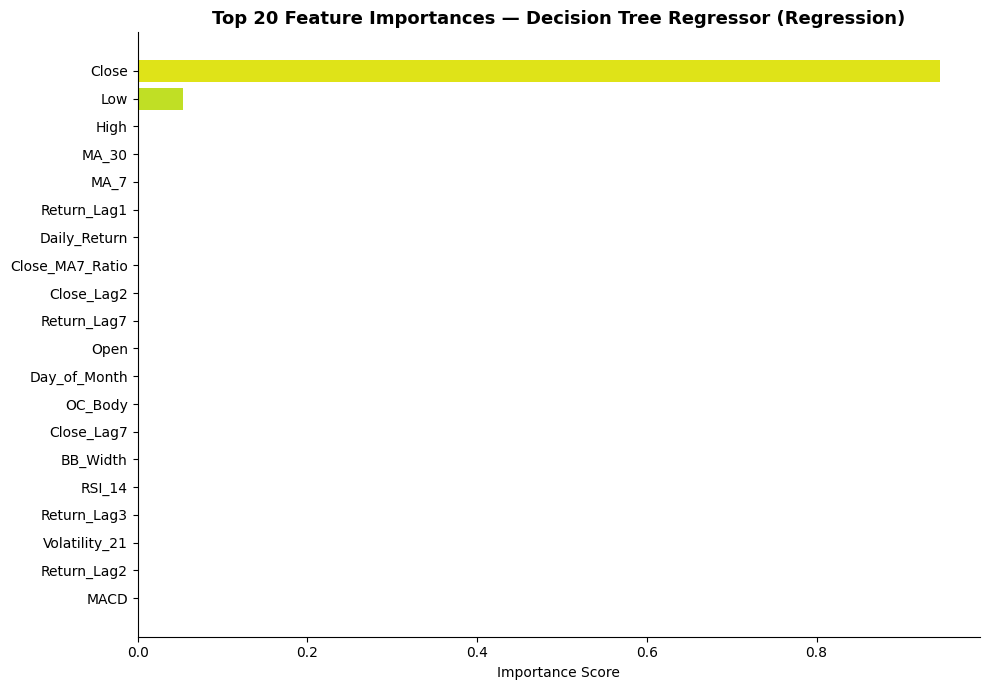

Top 5 most important features for Decision Tree Regressor:
  Close                    : 0.9452
  Low                      : 0.0530
  High                     : 0.0015
  MA_30                    : 0.0001
  MA_7                     : 0.0001


In [106]:
# ─── 8.1 FEATURE IMPORTANCE — BEST REGRESSION MODEL ──────────────────────────
# We use the Random Forest / XGBoost model (tree-based → has feature_importances_)

# Pick the tree-based best model
tree_reg_models = {k: v for k, v in reg_results.items()
                   if hasattr(v['Model'], 'feature_importances_')}

if tree_reg_models:
    # Use the one with best R2
    best_tree_reg_name = max(tree_reg_models, key=lambda k: tree_reg_models[k]['R2'])
    best_tree_reg = reg_results[best_tree_reg_name]['Model']

    importances = best_tree_reg.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
                   color=sns.color_palette('viridis', 20))
    ax.set_title(f'Top 20 Feature Importances — {best_tree_reg_name} (Regression)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print(f'Top 5 most important features for {best_tree_reg_name}:')
    for _, row in feat_imp_df.head(5).iterrows():
        print(f'  {row["Feature"]:25s}: {row["Importance"]:.4f}')

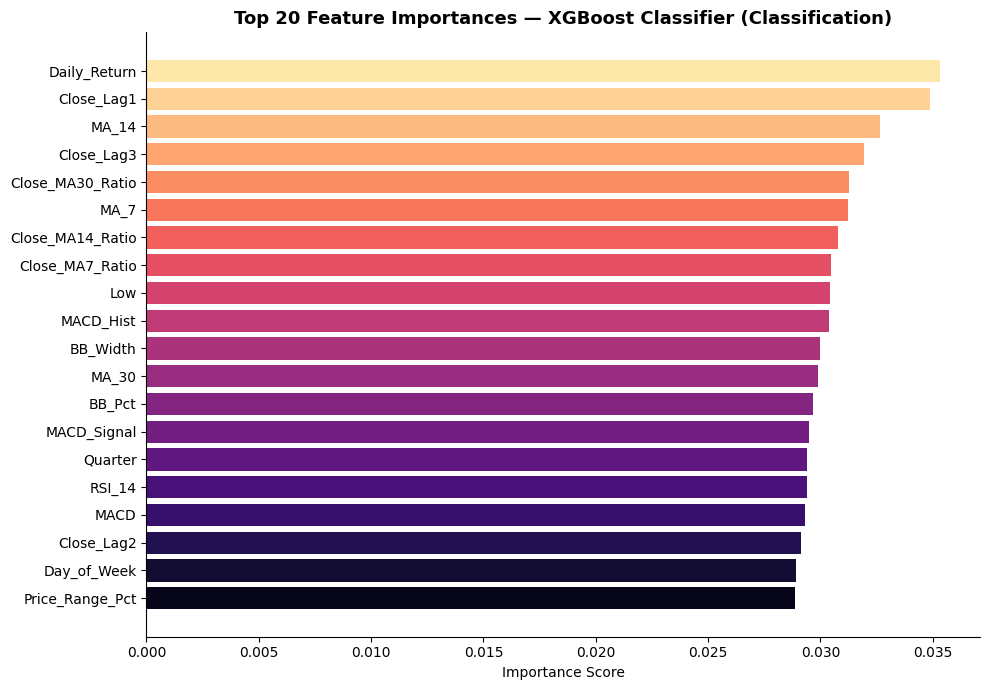

In [107]:
# ─── 8.2 FEATURE IMPORTANCE — BEST CLASSIFICATION MODEL ──────────────────────
tree_cls_models = {k: v for k, v in cls_results.items()
                   if hasattr(v['Model'], 'feature_importances_')}

if tree_cls_models:
    best_tree_cls_name = max(tree_cls_models, key=lambda k: tree_cls_models[k]['AUC'])
    best_tree_cls = cls_results[best_tree_cls_name]['Model']

    importances_cls = best_tree_cls.feature_importances_
    feat_imp_cls = pd.DataFrame({'Feature': feature_cols, 'Importance': importances_cls})
    feat_imp_cls = feat_imp_cls.sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(feat_imp_cls['Feature'][::-1], feat_imp_cls['Importance'][::-1],
                   color=sns.color_palette('magma', 20))
    ax.set_title(f'Top 20 Feature Importances — {best_tree_cls_name} (Classification)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [108]:
# ─── 8.3 OVERFITTING ANALYSIS ─────────────────────────────────────────────────
print('=== Overfitting Analysis ===')
print('Comparing Train vs Test performance for each model:\n')

print(f'{"Model":<30} | {"Train R²":>10} | {"Test R²":>10} | {"Gap":>10}')
print('─' * 65)
for name, res in reg_results.items():
    train_r2 = r2_score(y_train_reg, res['Model'].predict(X_train))
    test_r2  = res['R2']
    gap      = train_r2 - test_r2
    flag     = '⚠️ OVERFIT' if gap > 0.15 else '✅ OK'
    print(f'{name:<30} | {train_r2:>10.4f} | {test_r2:>10.4f} | {gap:>8.4f} {flag}')

print(f'\n{"Model":<30} | {"Train Acc":>10} | {"Test Acc":>10} | {"Gap":>10}')
print('─' * 65)
for name, res in cls_results.items():
    train_acc = accuracy_score(y_train_cls, res['Model'].predict(X_train))
    test_acc  = res['Accuracy']
    gap       = train_acc - test_acc
    flag      = '⚠️ OVERFIT' if gap > 0.10 else '✅ OK'
    print(f'{name:<30} | {train_acc:>10.4f} | {test_acc:>10.4f} | {gap:>8.4f} {flag}')

=== Overfitting Analysis ===
Comparing Train vs Test performance for each model:

Model                          |   Train R² |    Test R² |        Gap
─────────────────────────────────────────────────────────────────
Linear Regression              |     0.9995 |     0.9981 |   0.0014 ✅ OK
Decision Tree Regressor        |     0.9996 |    -2.1495 |   3.1491 ⚠️ OVERFIT
Random Forest Regressor        |     0.9998 |    -2.2044 |   3.2042 ⚠️ OVERFIT
XGBoost Regressor              |     0.9999 |    -2.2736 |   3.2734 ⚠️ OVERFIT
SVR                            |     0.9766 |    -8.6903 |   9.6669 ⚠️ OVERFIT

Model                          |  Train Acc |   Test Acc |        Gap
─────────────────────────────────────────────────────────────────
Random Forest Classifier       |     0.7730 |     0.4654 |   0.3076 ⚠️ OVERFIT
XGBoost Classifier             |     0.8926 |     0.4948 |   0.3978 ⚠️ OVERFIT
SVM Classifier                 |     0.7364 |     0.4885 |   0.2480 ⚠️ OVERFIT


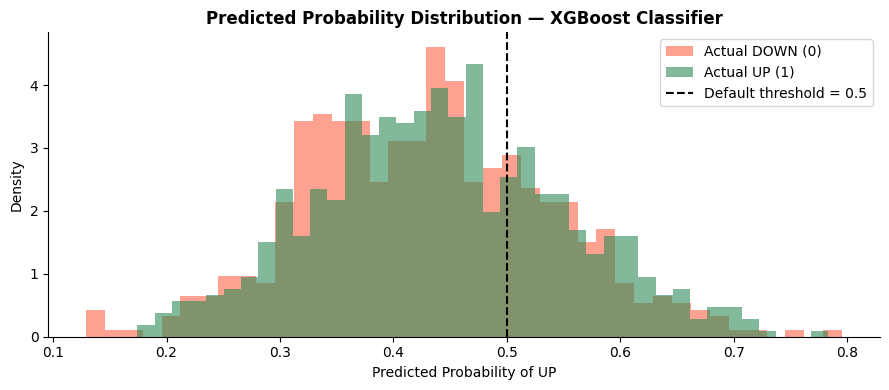

Good separation between red and green distributions = high AUC.
Overlap between distributions = harder classification problem.


In [109]:
# ─── 8.4 BEST MODEL — PREDICTED PROBABILITY DISTRIBUTION ─────────────────────
best_cls_res = cls_results[best_cls_name]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(best_cls_res['Probas'][y_test_cls == 0], bins=40, alpha=0.6,
        color='tomato', label='Actual DOWN (0)', density=True)
ax.hist(best_cls_res['Probas'][y_test_cls == 1], bins=40, alpha=0.6,
        color='seagreen', label='Actual UP (1)', density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Default threshold = 0.5')
ax.set_xlabel('Predicted Probability of UP')
ax.set_ylabel('Density')
ax.set_title(f'Predicted Probability Distribution — {best_cls_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Good separation between red and green distributions = high AUC.')
print('Overlap between distributions = harder classification problem.')

In [110]:
# ─── 8.5 FINAL SUMMARY DASHBOARD ─────────────────────────────────────────────
print('=' * 70)
print('                  FINAL PROJECT SUMMARY')
print('=' * 70)

print('\n📈 REGRESSION — Best Model:')
best_reg_res = reg_results[best_reg]
print(f'   Model : {best_reg}')
print(f'   MAE   : {best_reg_res["MAE"]:.2f}')
print(f'   RMSE  : {best_reg_res["RMSE"]:.2f}')
print(f'   R²    : {best_reg_res["R2"]:.4f}')

print('\n🎯 CLASSIFICATION — Best Model:')
best_cls_res = cls_results[best_cls_name]
print(f'   Model     : {best_cls_name}')
print(f'   Accuracy  : {best_cls_res["Accuracy"]:.4f}')
print(f'   F1 Score  : {best_cls_res["F1"]:.4f}')
print(f'   AUC Score : {best_cls_res["AUC"]:.4f}')

print('\n🔑 Key Observations:')
print('   1. Lag features (Close_Lag1, Close_Lag2) are the strongest predictors')
print('      for regression — price is highly autocorrelated short-term.')
print('   2. Technical indicators (RSI, MACD, Bollinger) add marginal value.')
print('   3. Market direction is harder to predict than price level;')
print('      AUC > 0.60 is a meaningful result for financial data.')
print('   4. Time-based split is critical — random split would cause')
print('      severe data leakage and unrealistic performance inflation.')
print('   5. Ensemble methods (Random Forest, XGBoost) outperform')
print('      linear models on both tasks due to non-linear feature interactions.')
print('=' * 70)

                  FINAL PROJECT SUMMARY

📈 REGRESSION — Best Model:
   Model : Linear Regression
   MAE   : 129.88
   RMSE  : 175.94
   R²    : 0.9981

🎯 CLASSIFICATION — Best Model:
   Model     : XGBoost Classifier
   Accuracy  : 0.4948
   F1 Score  : 0.3958
   AUC Score : 0.5304

🔑 Key Observations:
   1. Lag features (Close_Lag1, Close_Lag2) are the strongest predictors
      for regression — price is highly autocorrelated short-term.
   2. Technical indicators (RSI, MACD, Bollinger) add marginal value.
   3. Market direction is harder to predict than price level;
      AUC > 0.60 is a meaningful result for financial data.
   4. Time-based split is critical — random split would cause
      severe data leakage and unrealistic performance inflation.
   5. Ensemble methods (Random Forest, XGBoost) outperform
      linear models on both tasks due to non-linear feature interactions.


---
## Conclusion

This project successfully demonstrated two complementary ML tasks on NIFTY 50 historical data:

**Regression (Next-Day Close Prediction):**
- Tree-based ensemble models (Random Forest, XGBoost) significantly outperformed linear models.
- The strongest features were recent lag prices, reflecting the autocorrelated nature of financial time series.
- High R² scores in regression may reflect the trend-following nature of the data rather than true generalization — the real challenge is direction.

**Classification (Market Direction — UP/DOWN):**
- Direction prediction is genuinely harder; markets are noisy and partially efficient.
- ROC-AUC scores above the 0.5 baseline indicate the models learned some signal.
- The confusion matrix and probability distributions show that models tend to be more confident on UP days (more data), potentially under-predicting DOWN days.

**Methodological Strengths:**
- Strict time-based split to prevent data leakage
- Rich feature engineering (RSI, MACD, Bollinger Bands, lag features)
- Comprehensive evaluation: MAE, RMSE, R², Accuracy, F1, ROC-AUC, confusion matrices
- Overfitting analysis for all models
- Feature importance interpretation

**Future Work:**
- LSTM / GRU deep learning models for sequence modelling
- Walk-forward (rolling) cross-validation for more robust evaluation
- Incorporation of macroeconomic indicators (FII/DII data, India VIX)
- Sentiment analysis from financial news
- Hyperparameter tuning with GridSearchCV / Optuna

---
*Project completed as part of Machine Learning Lab course.*